<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Short Course - Lecture 4: Classification and Neural Networks

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

## Outline for Today

**Part I: Classification and Logistic Regression**
- From regression to classification
- The Iris dataset
- Bernoulli distribution and the sigmoid function
- NLL derivation and the cross-entropy loss
- Binary and multinomial logistic regression

**Part II: Neural Networks**
- From logistic regression to stacking layers
- Activation functions and architecture choices
- Loss functions from the Bayesian perspective
- Data preparation and PyTorch basics
- Building and training an ANN
- Backpropagation and automatic differentiation

In [1]:
# Basic imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from IPython.display import display, Math

%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8,4)

import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

---
# Part I: Classification and Logistic Regression

*From continuous to discrete predictions*

## Classification vs Regression

So far we have studied **regression**: predicting a continuous target $y \in \mathbb{R}$.

Now we turn to **classification**: predicting a discrete target $y \in \{1, 2, \ldots, C\}$.

Examples:
- Is this email spam or not? ($C=2$)
- What species of flower is this? ($C=3$)
- What digit is in this image? ($C=10$)

The good news: **if you understand regression, classification is almost the same thing!**

## The Iris Dataset

A classic benchmark dataset (Fisher, 1936): classify iris flowers into 3 species.

<div><img style="float: left"; src=../figures/iris_dataset_explanation.png width=350px></div>

**4 features:** sepal length, sepal width, petal length, petal width

**3 classes:** Iris-setosa, Iris-versicolor, Iris-virginica (50 samples each, 150 total)

**Task:** Given the 4 measurements, predict the species.

In [2]:
# Load the Iris dataset
iris_data = pd.read_csv('../data/data_iris.csv')
print(f"Shape: {iris_data.shape}")
iris_data.head()

Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Extract features and targets
feature1 = 'SepalLengthCm'
feature2 = 'SepalWidthCm'
X_2d_iris_data = iris_data.loc[:, [feature1, feature2]].values  # just 2 features for visualization
y_string_iris_data = iris_data.loc[:, 'Species'].values
target_names = iris_data.loc[:, 'Species'].unique()

# Convert string targets to integers
y_iris_data = pd.Categorical(pd.factorize(y_string_iris_data)[0])
print(f"Target names: {target_names}")
print(f"Encoded targets: {y_iris_data.unique()}")

Target names: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded targets: [0, 1, 2]
Categories (3, int64): [0, 1, 2]


## What distribution should we use?

For regression, we used a **Gaussian** distribution for the observation model:
$$p(y|\mathbf{x}, \mathbf{z}) = \mathcal{N}(y | \mu, \sigma^2) \quad \text{(continuous } y \text{)}$$

For binary classification ($C=2$), the target is $y \in \{0, 1\}$, so we need:
$$p(y|\mathbf{x}, \mathbf{z}) = \text{Ber}(y | \rho) = \rho^y(1-\rho)^{1-y} \quad \text{(discrete } y \text{)}$$

where $\rho \in [0, 1]$ is the probability of class 1.

Text(0.5, 1.0, 'Bernoulli distribution for $\\rho = $0.6')

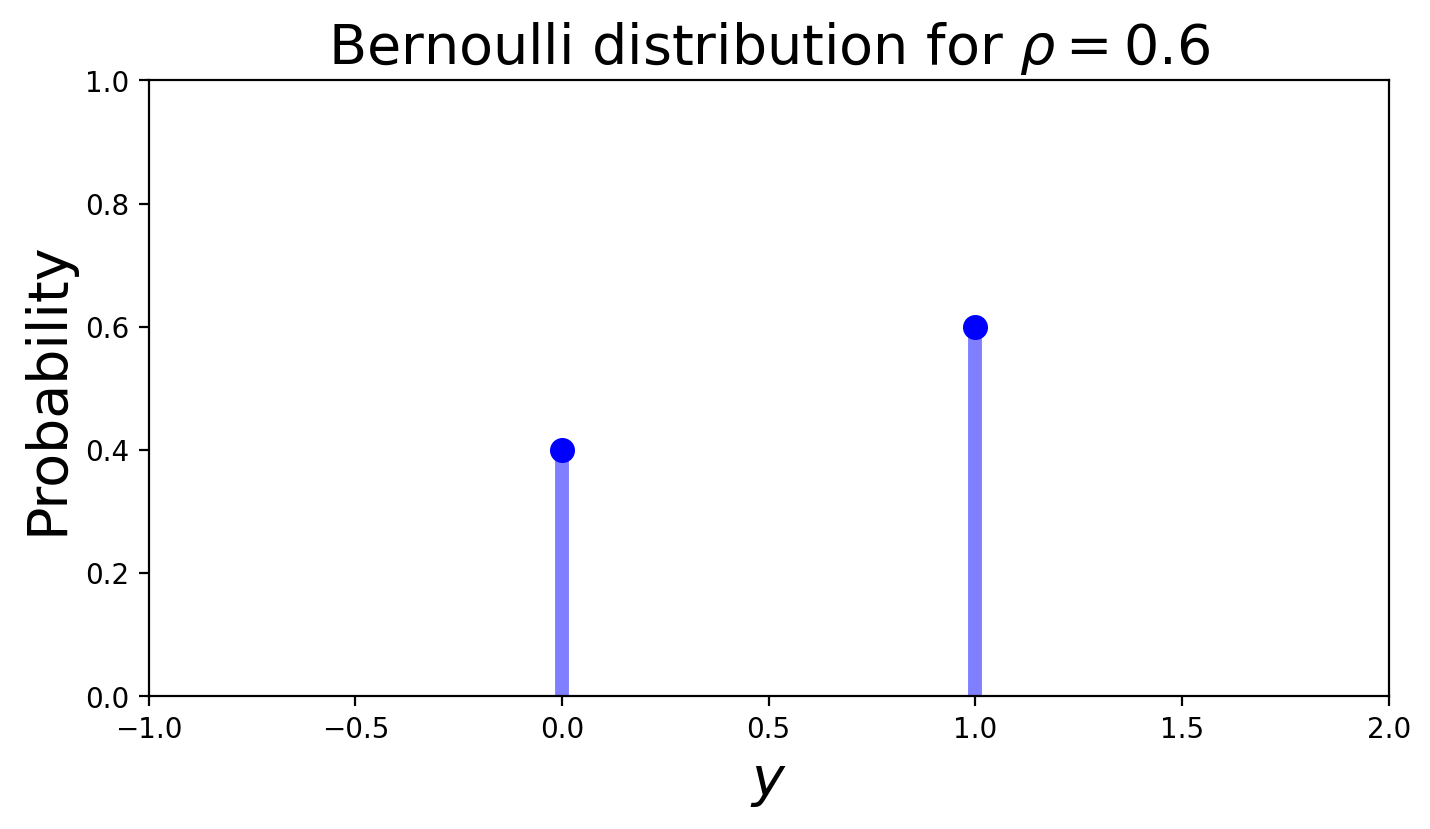

In [4]:
# Plot the Bernoulli distribution
from scipy.stats import bernoulli
fig_b, ax_b = plt.subplots(1, 1)

rho = 0.6  # mean of Bernoulli distribution
y = [0, 1]

ax_b.plot(y, bernoulli.pmf(y, rho), 'bo', ms=8, label='Bernoulli PMF')
ax_b.vlines(y, 0, bernoulli.pmf(y, rho), colors='b', lw=5, alpha=0.5)
ax_b.set_xlim([-1, 2])
ax_b.set_ylim([0, 1])
ax_b.set_xlabel('$y$', fontsize=20)
ax_b.set_ylabel('Probability', fontsize=20)
ax_b.set_title(r'Bernoulli distribution for $\rho = $%1.1f' % rho, fontsize=20)

## The sigmoid function

We need to model $\rho$ as a function of the input: $\rho = f(\mathbf{x}, \mathbf{z})$.

But $\rho$ must satisfy $0 \leq \rho \leq 1$. How do we ensure this?

Use the **sigmoid function** to map any real number to $[0, 1]$:

$$\sigma(a) = \frac{1}{1 + e^{-a}}$$

Key properties:
- Maps $\mathbb{R} \rightarrow [0, 1]$
- Derivative: $\frac{d}{da}\sigma(a) = \sigma(a)(1 - \sigma(a))$
- Inverse (logit): $\sigma^{-1}(p) = \log\frac{p}{1-p}$

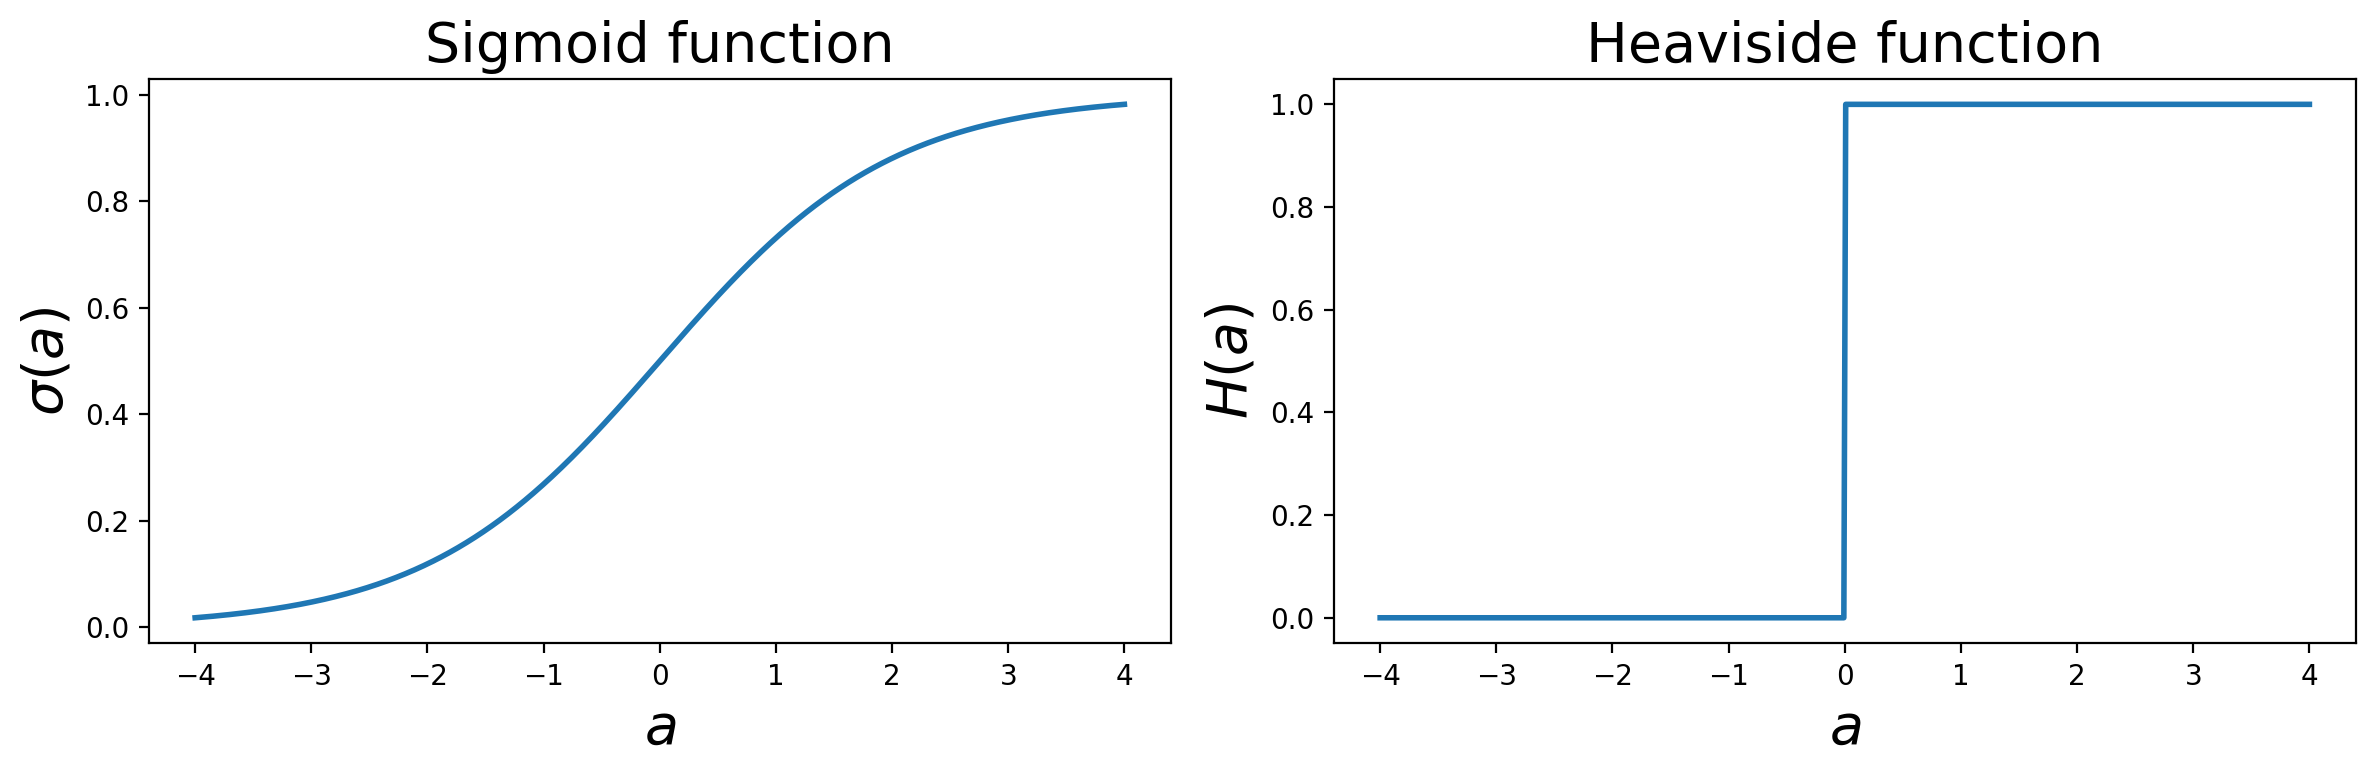

In [5]:
# Plot sigmoid vs Heaviside function
a = np.linspace(-4, 4, 1001)
sigmoid = 1 / (1 + np.exp(-a))

fig_s, (ax_s1, ax_s2) = plt.subplots(1, 2)
ax_s1.plot(a, sigmoid, linewidth=2)
ax_s1.set_title("Sigmoid function", fontsize=20)
ax_s1.set_xlabel("$a$", fontsize=20)
ax_s1.set_ylabel(r"$\sigma(a)$", fontsize=20)

heaviside = np.heaviside(a, 0.5)
ax_s2.plot(a, heaviside, linewidth=2)
ax_s2.set_title("Heaviside function", fontsize=20)
ax_s2.set_xlabel("$a$", fontsize=20)
ax_s2.set_ylabel(r"$H(a)$", fontsize=20)
fig_s.set_size_inches(12, 4)
plt.tight_layout()

## Defining the model

We model the Bernoulli parameter $\rho$ using a linear function passed through the sigmoid:

$$\rho = \sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}))$$

The model parameters are weights $\mathbf{w} = [w_0, w_1, \ldots, w_{M-1}]^T$ applied to basis functions $\boldsymbol{\phi}(\mathbf{x})$.

**Example:** 2D input with quadratic polynomial basis ($M=6$):
$$\rho = \sigma(w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1 x_2 + w_4 x_1^2 + w_5 x_2^2)$$

The sigmoid ensures $0 \leq \rho \leq 1$ for any values of the weights!

## Binary Logistic Regression model

We are now ready to define the logistic regression model.

**1. Bernoulli observation distribution:**
$$p(y|\mathbf{x}, \mathbf{z}) = \text{Ber}\left(y \,\middle|\, \rho = \sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}))\right)$$

where $\mathbf{z} = \mathbf{w}$ are all the unknown model parameters (hidden rv's).

**2. Uniform prior:** $p(\mathbf{z}) \propto 1$ (or Gaussian prior for regularization)

**3. MLE point estimate:** $\hat{\mathbf{z}}_{\text{mle}} = \underset{z}{\mathrm{argmin}}\left[-\sum_{i=1}^{N}\log{ p(y_i|\mathbf{x}_i, \mathbf{z})}\right]$

The <font color='orange'>PPD</font>: $\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = p(y^*|\mathbf{x}^*, \mathbf{z}=\hat{\mathbf{z}})$

Final class prediction is the **mode** of the PPD: $y^* = \underset{y}{\mathrm{argmax}}\left[ p(y|\mathbf{x}^*, \mathbf{z}=\hat{\mathbf{z}}) \right]$

## Regression vs Classification:

Now is a good time to stop and think about the differences between a regression model and a classification model.

Let's play a game!

In [6]:
from scipy.stats import norm, bernoulli as bernoulli_dist

# Define the function y = x * sin(x)
def f_reg(x):
    return x * np.sin(x)

def Gaussian_PPD_riding_mean_prediction(point_x=1.0):
    xmin, xmax, npoints = 0.0, 8.0, 100
    x_func = np.linspace(xmin, xmax, npoints)
    y_func = f_reg(x_func)
    point_y = f_reg(point_x)
    mean, std_dev = point_y, 1.0
    ymin = np.min(y_func) - 2*std_dev
    ymax = np.max(y_func) + 2*std_dev
    y_values = np.linspace(mean - 1.96*std_dev, mean + 1.96*std_dev, 100)
    pdf_values = norm.pdf(y_values, mean, std_dev)
    pdf_scaled = pdf_values / np.max(pdf_values) * (xmax-xmin) / 20

    fig, ax = plt.subplots(1, 1)
    ax.plot(pdf_scaled + point_x, y_values, color='orange',
            label=r'PPD: $\mathcal{N}(y^*|x^*=%2.2f, \mathcal{D})$' % point_x)
    ax.fill_betweenx(y_values, pdf_scaled + point_x, point_x, color='orange', alpha=0.25)
    ax.plot(x_func, y_func, label=r'Predicted mean: $\mu^*(x)$', color='black')
    ax.scatter([point_x], [point_y], color='orange', marker="*",
              label=r'$\mu^*(x=%2.2f)$' % point_x)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title('Schematic of Regression model and its PPD at a point')
    ax.set_xlabel('X-axis'); ax.set_ylabel('Y-axis')
    ax.axis([xmin, xmax, ymin, ymax])
    ax.legend(); ax.grid()
    fig.set_size_inches(6, 3)

In [7]:
# Interactive regression PPD plot
from ipywidgets import interactive
interactive_plot = interactive(Gaussian_PPD_riding_mean_prediction, point_x=(0.0, 8.0))
interactive_plot

interactive(children=(FloatSlider(value=1.0, description='point_x', max=8.0), Output()), _dom_classes=('widget…

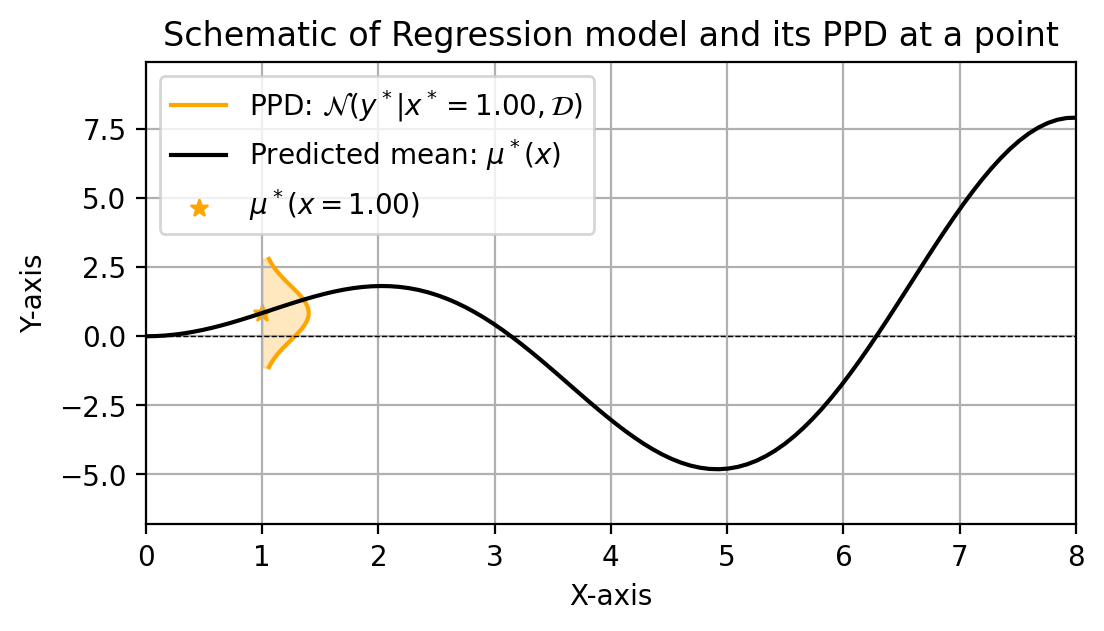

In [8]:
# Static version (for non-interactive environments)
Gaussian_PPD_riding_mean_prediction(point_x=1.0)

In [9]:
# Define functions for the classification interactive demo
def true_function(x, jump_location):
    return np.heaviside(x - jump_location, 0.5)

def sigmoid_fn(a):
    return 1 / (1 + np.exp(-a))

def f_x_comma_z(x, z):
    return z[0] + x * z[1]

def Bernoulli_PPD_riding_mean_prediction(point_x=1.5, w_0=0.0, w_1=1.0):
    xmin, xmax, npoints = 0.0, 8.0, 1000
    jump_location = 4.0
    x_func = np.linspace(xmin, xmax, npoints)
    y_func = true_function(x_func, jump_location)
    ymin, ymax = -2.0, 2.0

    z = [w_0, w_1]
    PPD_mean_at_point = sigmoid_fn(f_x_comma_z(point_x, z))
    PPD_mean = sigmoid_fn(f_x_comma_z(x_func, z))

    y_pmf = [0, 1]
    pmf_values = bernoulli_dist.pmf(y_pmf, PPD_mean_at_point)

    fig, ax = plt.subplots(1, 1)
    ax.plot(x_func, y_func, label=r'Ground truth', color='black', linewidth=2.0)
    ax.plot(pmf_values + point_x, y_pmf, 'bo', ms=8, label='PPD: Bernoulli distribution')
    ax.hlines(y_pmf, pmf_values + point_x, point_x, colors='b', lw=5, alpha=0.5)
    ax.vlines(point_x, 0.0, 1.0, color='black', linewidth=2.5, linestyle='--')
    ax.plot(x_func, f_x_comma_z(x_func, z),
            label=r'$f(x,\mathbf{z})$ with $\mathbf{z}=[w_0=%2.1f, w_1=%2.1f]^T$' % (w_0, w_1),
            color='red', linewidth=1.0, linestyle='--')
    ax.plot(x_func, PPD_mean,
            label=r'PPD mean: $\rho^*(x)=\sigma[f(x^*,\mathbf{z})]$',
            color='orange', linewidth=2.0, linestyle='--')
    ax.scatter([point_x], [PPD_mean_at_point], color='orange', marker="o", s=50,
              label=r'Mean of PPD: $\rho^*(x=%2.2f)$' % point_x)
    PPD_mode = 1.0 if PPD_mean_at_point >= 0.5 else 0.0
    ax.scatter([point_x], [PPD_mode], color='blue', marker="*", s=200,
              label=r'Mode of PPD: $y^*(x=%2.2f)$' % point_x)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title('Schematic of Classification model and its PPD at a point')
    ax.set_xlabel('X-axis'); ax.set_ylabel('Y-axis')
    ax.axis([xmin, xmax, ymin, ymax])
    ax.legend(loc='lower right'); ax.grid()
    fig.set_size_inches(8, 4)

In [10]:
# Interactive classification PPD plot
interactive_plot = interactive(Bernoulli_PPD_riding_mean_prediction,
                               point_x=(0.0, 8.0), w_0=(-4.0, 0.0), w_1=(-1.0, 1.0))
interactive_plot

interactive(children=(FloatSlider(value=1.5, description='point_x', max=8.0), FloatSlider(value=0.0, descripti…

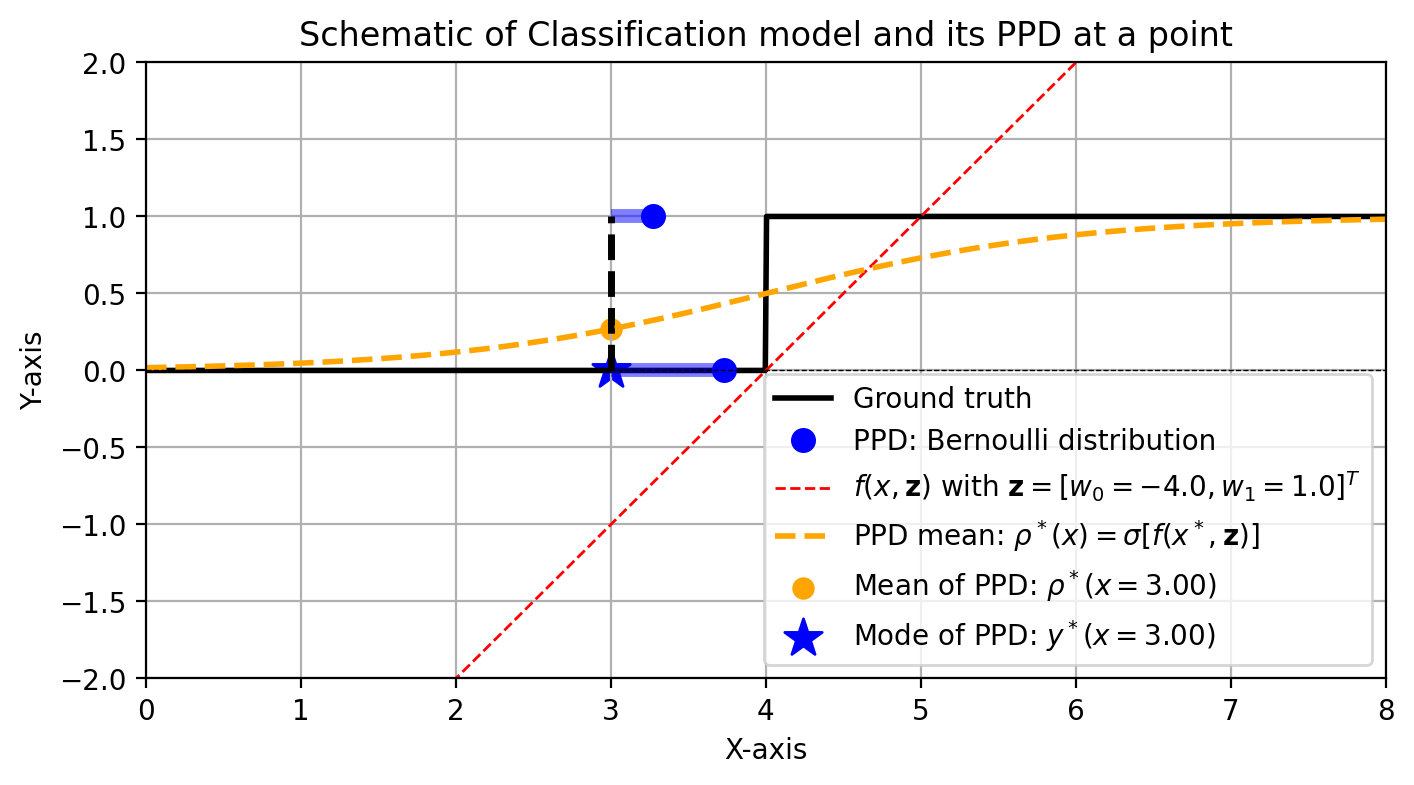

In [11]:
# Static version (for non-interactive environments)
Bernoulli_PPD_riding_mean_prediction(point_x=3.0, w_0=-4.0, w_1=1.0)

## The NLL for Logistic Regression

Like we did before for other models, let's determine the PPD from the MLE point estimate:

$\begin{align}
\text{NLL}(\mathbf{w}) =& -\log \prod_{n=1}^N \text{Ber}(y_n|\rho_n)\\
=& -\sum_{n=1}^N \log [\rho_n^{y_n}\times(1-\rho_n)^{1-y_n}]\\
=& -\sum_{n=1}^N [y_n\log \rho_n + (1-y_n)\log(1-\rho_n)]\\
=& \sum_{n=1}^N \mathbb{H}(y_n,\rho_n)
\end{align}$

where $\rho_n = \sigma(a_n)$, $a_n = \mathbf{w}^T\boldsymbol{\phi}(\mathbf{x}_n)$ is the log odds, and $\mathbb{H}(y_n,\rho_n)$ is the **binary cross-entropy** loss:

$$\mathbb{H}(p,q) = -[p\log q + (1-p)\log(1-q)]$$

## Finding the MLE: gradient of the NLL

As usual, how do we find the MLE point estimate?

Minimize the NLL by setting the gradient to zero:

$$\nabla_{\mathbf{w}}\text{NLL}(\mathbf{w}) = \mathbf{0}$$

## Computing the gradient (step by step)

$$\nabla_{\mathbf{w}}\text{NLL}(\mathbf{w}) = -\sum_{n=1}^N [y_n\color{blue}{\nabla_{\mathbf{w}}\log \rho_n} + (1-y_n)\color{green}{\nabla_{\mathbf{w}}\log(1-\rho_n)}]$$

The colored terms both depend on $\color{red}{\nabla_{\mathbf{w}}\rho_n}$:
- $\color{blue}{\nabla_{\mathbf{w}}\log \rho_n} = \frac{1}{\rho_n}\color{red}{\nabla_{\mathbf{w}}\rho_n}$
- $\color{green}{\nabla_{\mathbf{w}}\log(1-\rho_n)} = -\frac{1}{1-\rho_n}\color{red}{\nabla_{\mathbf{w}}\rho_n}$

Using the sigmoid derivative $\frac{d}{da}\sigma(a) = \sigma(a)(1-\sigma(a))$ and the chain rule:

$$\color{red}{\nabla_{\mathbf{w}}\rho_n} = \rho_n(1-\rho_n)\boldsymbol{\phi}(\mathbf{x}_n)$$

## The gradient simplifies beautifully

Substituting back:

$\begin{align}
\nabla_{\mathbf{w}}\text{NLL}(\mathbf{w}) &= -\sum_{n=1}^N [y_n\color{blue}{(1-\rho_n)\boldsymbol{\phi}(\mathbf{x}_n)} - (1-y_n)\color{green}{\rho_n\boldsymbol{\phi}(\mathbf{x}_n)}]\\
&= \sum_{n=1}^N \boldsymbol{\phi}(\mathbf{x}_n)(\rho_n - y_n)
\end{align}$

This has a nice intuitive interpretation: the gradient is the sum of the differences between the prediction $\rho_n$ and the observed target $y_n$, weighted by the input basis vectors $\boldsymbol{\phi}(\mathbf{x}_n)$.

In matrix form: $\nabla_{\mathbf{w}}\text{NLL}(\mathbf{w}) = \boldsymbol{\Phi}^T(\boldsymbol{\rho} - \mathbf{y})$

**Note**: Here are all the intermediate steps for the sigmoid derivative:

$\begin{align}
\color{red}{\frac{\partial}{\partial w_d}\rho_n} &= \frac{\partial}{\partial w_d}\sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n))\\
&= \frac{\partial}{\partial a_n}\sigma(a_n) \frac{\partial a_n}{\partial w_d} \quad \text{(chain rule, where } a_n = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) \text{)}\\
&= \sigma(a_n)(1-\sigma(a_n))\phi_{d}(\mathbf{x}_n) \quad \text{(sigmoid derivative)}\\
&= \rho_n(1-\rho_n)\phi_{d}(\mathbf{x}_n)
\end{align}$

In vector form: $\color{red}{\nabla_{\mathbf{w}}\rho_n} = \rho_n(1-\rho_n)\boldsymbol{\phi}(\mathbf{x}_n)$

## A small problem...

Setting the gradient to zero:

$$\nabla_{\mathbf{w}}\text{NLL}(\mathbf{w}) = \mathbf{0} \quad \Rightarrow \quad \sum_{n=1}^N \boldsymbol{\phi}(\mathbf{x}_n)\left[\sigma\left(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\right) - y_n\right] = \mathbf{0}$$

Can you see the problem?

We **cannot** explicitly solve for $\mathbf{w}$ because the sigmoid makes the expression **nonlinear** in the weights!

This did not happen in Linear Regression (Lecture 2), where we found a closed-form solution.

What do we do now? Any ideas??

## Point estimate via optimization

Since we have expressions for both the NLL and its gradient:

$$\text{NLL}(\mathbf{w}) = -\sum_{n=1}^N [y_n\log \rho_n + (1-y_n)\log(1-\rho_n)]$$

$$\nabla_{\mathbf{w}}\text{NLL}(\mathbf{w}) = \boldsymbol{\Phi}^T(\boldsymbol{\rho} - \mathbf{y})$$

we can use a **gradient-based optimization algorithm** to find the minimum of the NLL!

The usual optimizer of choice is **L-BFGS** (the same we used for Gaussian processes).

**Good news:** The NLL is actually **convex** (the Hessian is positive semi-definite), so the optimizer will find the global optimum.

#### Note on the Hessian of NLL for logistic regression

$$\mathbf{H}(\mathbf{w}) = \nabla_{\mathbf{w}}\nabla_{\mathbf{w}}^T \text{NLL}(\mathbf{w}) = \sum_{n=1}^N \rho_n (1-\rho_n)\boldsymbol{\phi}(\mathbf{x}_n)\boldsymbol{\phi}(\mathbf{x}_n)^T = \boldsymbol{\Phi}^T\mathbf{S}\boldsymbol{\Phi}$$

where $\mathbf{S} = \text{diag}(\rho_1(1-\rho_1), \ldots, \rho_N(1-\rho_N))$. For any nonzero vector $\mathbf{v}$:

$$\mathbf{v}^T\boldsymbol{\Phi}^T\mathbf{S}\boldsymbol{\Phi}\mathbf{v} = ||\mathbf{S}^{1/2}\boldsymbol{\Phi}\mathbf{v}||_2^2 > 0$$

so $\mathbf{H}$ is positive definite and the NLL is strictly convex.

## Practical notes

**1. Regularization:** It can be useful to use a Gaussian prior on the weights (like in linear regression). This is especially important when the problem is **perfectly separable** — i.e., a straight line can perfectly separate the classes. In that case, the slope of the sigmoid becomes infinite. Regularization prevents this.

**2. Overparameterization:** Higher-order polynomial basis functions make perfect separation more likely. The decision boundary becomes "wavy" and starts overfitting.

Remember the kernel trick from GPs? One popular classification algorithm that uses kernels is the **Support Vector Machine** (SVM).

## Prediction with the point estimate

Once the optimizer provides us with the point estimate $\hat{\mathbf{z}} = \color{red}{\hat{\mathbf{w}}}$, we get our prediction via the <font color='orange'>PPD</font>:

$$\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})} = \text{Ber}\left(y^* \,\middle|\, \rho^* = \sigma\left(\color{red}{\hat{\mathbf{w}}}^T \boldsymbol{\phi}(\mathbf{x}^*)\right)\right)$$

Let's see this in action on the Iris dataset!

## Logistic regression on Iris (2D)

Let's train a logistic regression classifier on 2 features of the Iris dataset and visualize the **decision boundaries**.

Text(0.5, 1.0, 'Logistic regression (degree 1)')

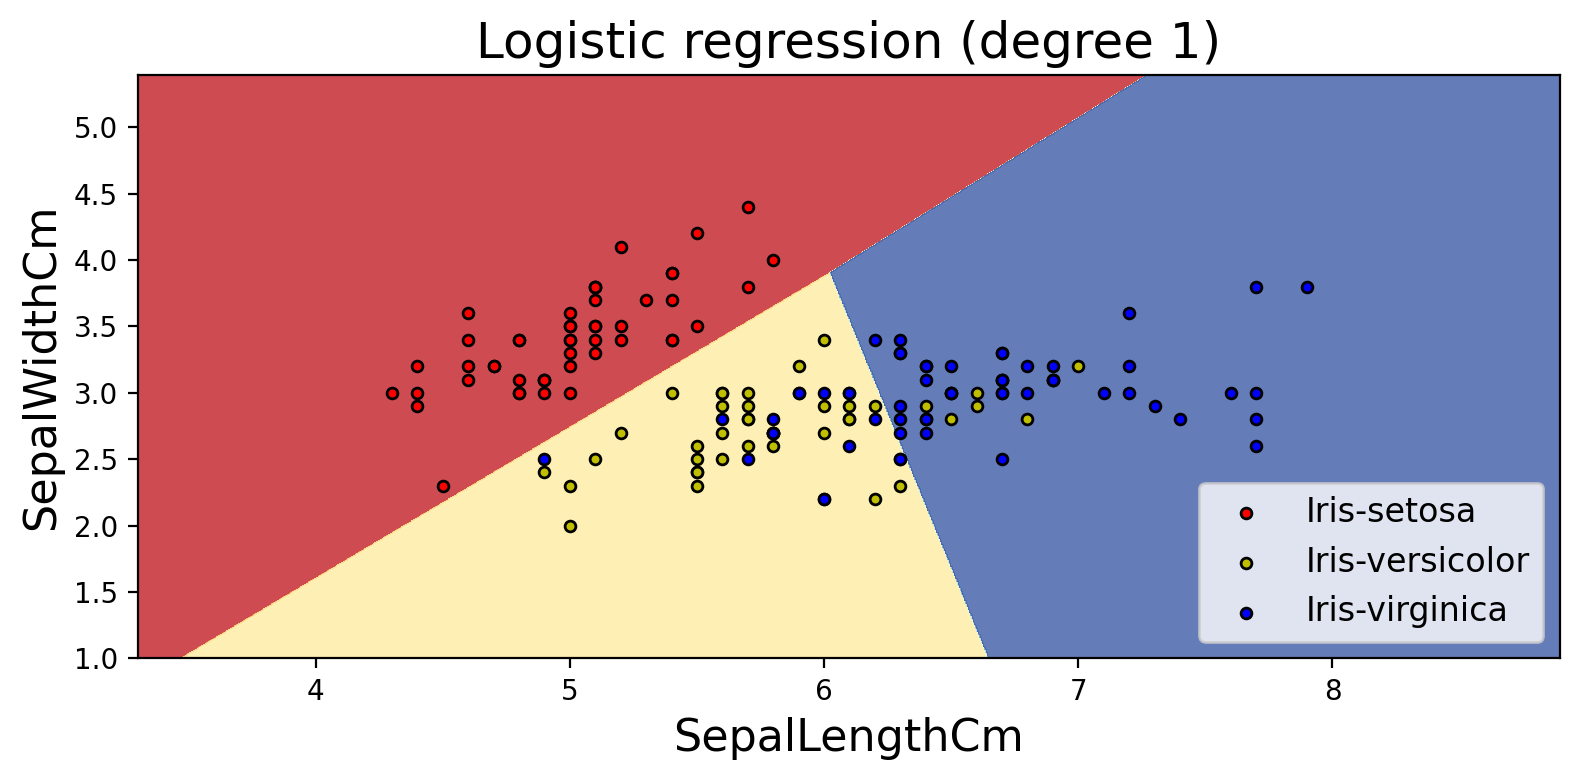

In [12]:
# Train logistic regression and plot decision boundaries
n_classes = 3
plot_colors = 'ryb'
plot_step = 5e-3

C = 1e5  # inverse regularization strength
degree = 1

LogReg_model = make_pipeline(PolynomialFeatures(degree), LogisticRegression(C=C, solver='lbfgs'))
LogReg_model.fit(X_2d_iris_data, y_iris_data)

# Create grid for decision boundary plot
x1_min, x1_max = X_2d_iris_data[:, 0].min() - 1, X_2d_iris_data[:, 0].max() + 1
x2_min, x2_max = X_2d_iris_data[:, 1].min() - 1, X_2d_iris_data[:, 1].max() + 1
X1_grid, X2_grid = np.meshgrid(np.arange(x1_min, x1_max, plot_step),
                               np.arange(x2_min, x2_max, plot_step))

y_pred_grid = LogReg_model.predict(np.c_[X1_grid.ravel(), X2_grid.ravel()])
Y_grid = y_pred_grid.reshape(X1_grid.shape)

fig_lr, ax_lr = plt.subplots(tight_layout=True)
ax_lr.contourf(X1_grid, X2_grid, Y_grid, cmap=cm.RdYlBu, alpha=0.8)
for i, color in zip(range(n_classes), plot_colors):
    idx = np.where(y_iris_data == i)
    ax_lr.scatter(X_2d_iris_data[idx, 0], X_2d_iris_data[idx, 1], c=color,
                  label=target_names[i], edgecolor='black', s=15)
ax_lr.set_xlabel(feature1, fontsize=16)
ax_lr.set_ylabel(feature2, fontsize=16)
ax_lr.legend(loc='lower right', fontsize=12)
ax_lr.set_title('Logistic regression (degree 1)', fontsize=18)

## 1D example: the decision boundary

To see the sigmoid in action, let's use only **1 feature** (Petal width) and **2 classes** (Iris-versicolor vs Iris-virginica).

This lets us visualize the probability curves $\rho$ and $1-\rho$ directly.

In [13]:
# Binary classification: 1 feature, 2 classes
feature_1d = 'PetalWidthCm'
x_1d = iris_data.loc[50:, feature_1d].values  # classes 2 and 3 only
y_1d_strings = iris_data.loc[50:, 'Species'].values
target_names_2c = iris_data.loc[50:, 'Species'].unique()
y_1d = pd.Categorical(pd.factorize(y_1d_strings)[0])

C = 1e5
LogReg_1d = LogisticRegression(C=C, solver='lbfgs')
LogReg_1d.fit(x_1d.reshape(-1, 1), y_1d)

# Predict probabilities on a fine grid
x_plot_1d = np.linspace(0, 3, 1000).reshape(-1, 1)
rho_plot = LogReg_1d.predict_proba(x_plot_1d)
decision_boundary = x_plot_1d[rho_plot[:, 0] < 0.5][0]

# Plot
fig_1d, ax_1d = plt.subplots(1, 1)
ax_1d.scatter(x_1d[y_1d == 0], y_1d[y_1d == 0].astype(int), s=15, c="r", marker="s")
ax_1d.scatter(x_1d[y_1d == 1], y_1d[y_1d == 1].astype(int), s=15, c="b", marker="^")
ax_1d.plot([decision_boundary[0], decision_boundary[0]], [-1, 2],
           color="black", linestyle=":", label="Decision boundary", linewidth=4.0)
ax_1d.plot(x_plot_1d, rho_plot[:, 0], "r-", label=target_names_2c[0])
ax_1d.plot(x_plot_1d, rho_plot[:, 1], "b--", label=target_names_2c[1])
ax_1d.arrow(decision_boundary[0], 0.08, -0.3, 0, head_width=0.05, head_length=0.1, fc="r", ec="r")
ax_1d.arrow(decision_boundary[0], 0.92, 0.3, 0, head_width=0.05, head_length=0.1, fc="b", ec="b")
ax_1d.set_xlabel(feature_1d, fontsize=20)
ax_1d.set_ylabel("Probability", fontsize=20)
ax_1d.set_title(r"Decision boundary with $\rho$ and $(1-\rho)$ probabilities", fontsize=16)
ax_1d.legend(bbox_to_anchor=(1, 1), fontsize=12)
ax_1d.axis([0, 3, -0.02, 1.02])
fig_1d.set_size_inches(8, 5)
plt.close(fig_1d)

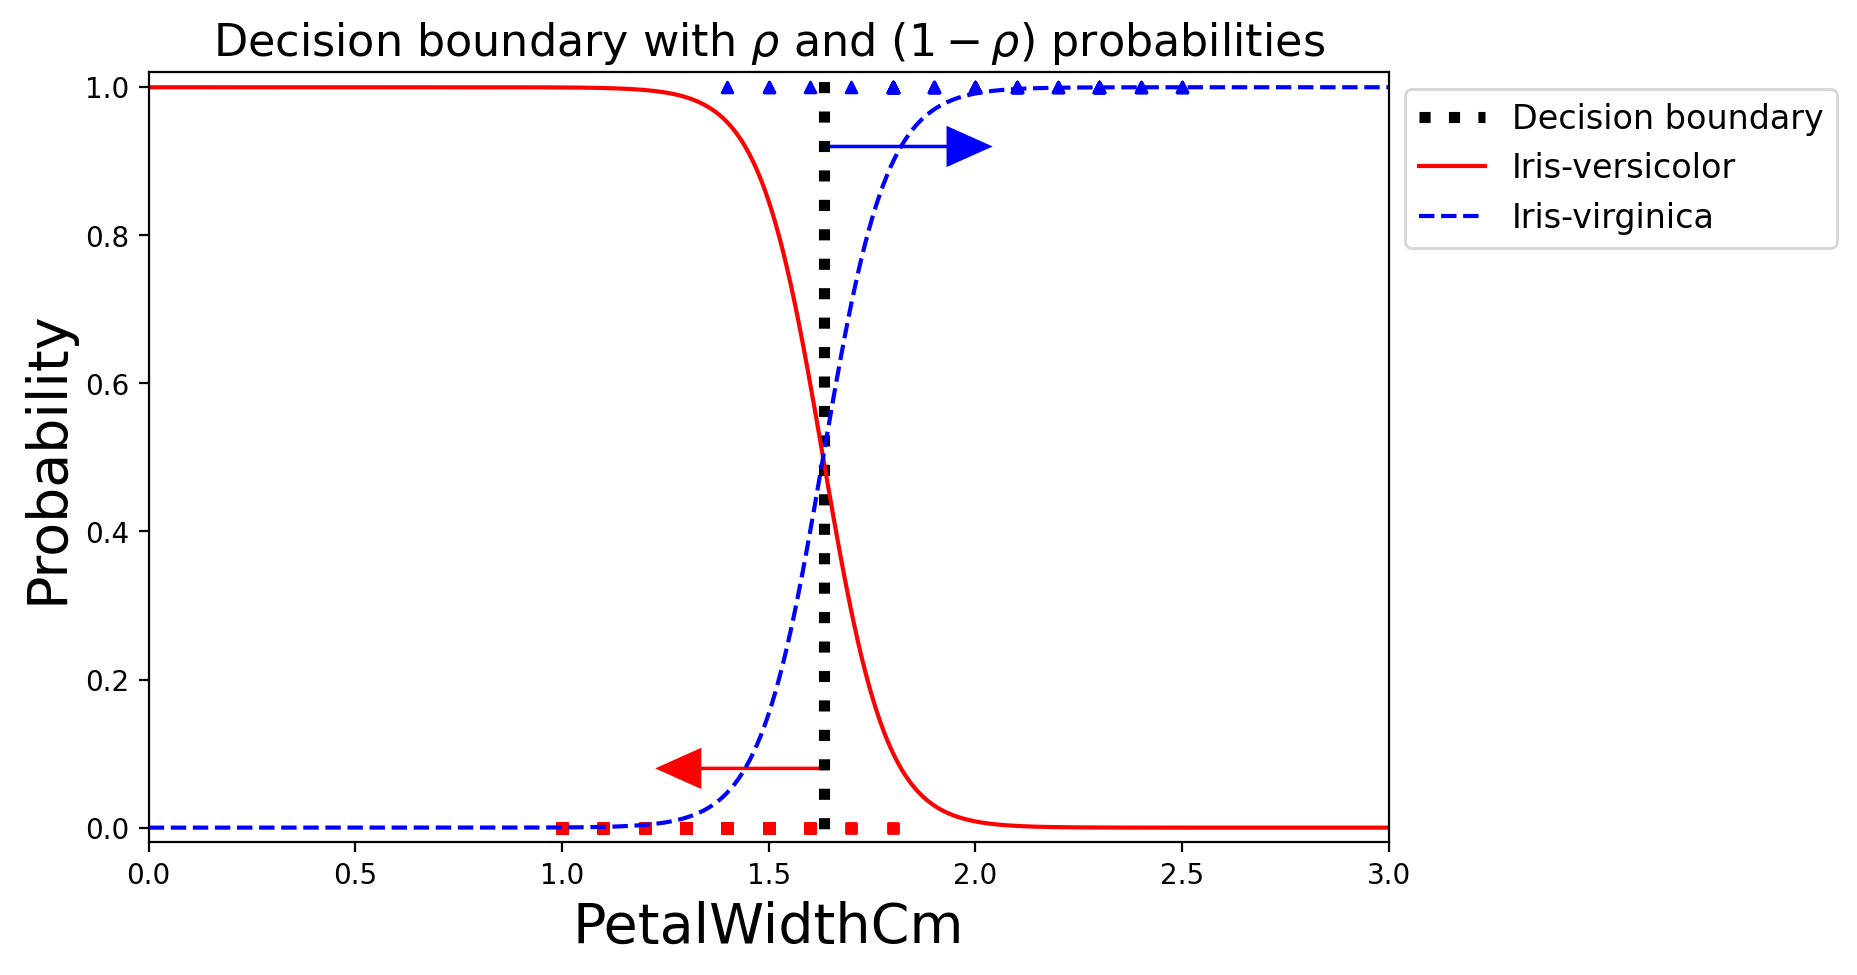

In [14]:
fig_1d

## Multinomial Logistic Regression

For $C > 2$ classes, we generalize from binary to **multinomial** logistic regression:

**Categorical distribution** (generalizes Bernoulli to $C$ classes):
$$\text{Cat}(y|\boldsymbol{\rho}) = \prod_{c=1}^{C} \rho_c^{\mathbb{1}(y=c)}$$

where $\rho_c = p(y=c)$ and $\sum_c \rho_c = 1$.

## The softmax function

The sigmoid maps $\mathbb{R} \rightarrow [0, 1]$. For multiple classes, we need the **softmax**:

$$\text{softmax}(\mathbf{a})_c = \frac{e^{a_c}}{\sum_{c'=1}^{C} e^{a_{c'}}}$$

This maps $\mathbb{R}^C \rightarrow$ the probability simplex (all outputs positive, sum to 1).

The multinomial logistic regression model is then:
$$p(y|\mathbf{x}, \mathbf{z}) = \text{Cat}\left(y \,\middle|\, \boldsymbol{\rho} = \text{softmax}(\mathbf{W}^T \boldsymbol{\phi}(\mathbf{x}))\right)$$

where $\mathbf{W}$ is now a **weight matrix** (one column per class).

## Multinomial NLL and gradient

For $C$ classes, the NLL becomes:

$$\text{NLL}(\mathbf{W}) = -\sum_{n=1}^N \sum_{c=1}^C y_{nc} \log \rho_{nc}$$

where $y_{nc}$ is the one-hot encoded target (1 if sample $n$ belongs to class $c$, 0 otherwise).

The gradient computation is analogous to the binary case. See Section 10.3.2 of Murphy's book for details.

## Can we be Bayesian about classification?

We can try to extend logistic regression to **Bayesian logistic regression** to capture uncertainty, but the posterior $p(\mathbf{w}|\mathcal{D})$ is **intractable**!

Unlike Bayesian linear regression (Lecture 2), the product of Bernoulli likelihoods and Gaussian prior does not give a Gaussian posterior.

Solutions exist (Laplace approximation, variational inference, MCMC) — see Section 10.5 of Murphy's book.

For now, we use the **MLE point estimate** (no uncertainty quantification).

## Other classifiers

Logistic regression is just one of many classifiers:
- **Support Vector Machines** (SVM): like a simplified/deterministic GP for classification
- **Decision Trees**: split feature space into regions (interpretable but can overfit)
- **Gaussian Process Classification**: Bayesian, but posterior is intractable
- **Neural Networks**: the focus of Parts II and III!

All use the same basic framework: choose a model, define a loss, optimize.

### In-class Exercise

Using the logistic regression code above, try:

1. Change the polynomial degree from 1 to 2 and then to 4. What happens to the decision boundary?
   - *Hint:* For degree > 2, use `solver='newton-cholesky'` instead of `'lbfgs'`
2. Use `PetalLengthCm` and `PetalWidthCm` as features instead. Is the classification easier?

In [15]:
# Write your code for the In-class Exercise:

# until here.

<details>
<summary><b>Click here for Solution</b></summary>

```python
# Part 1: Higher polynomial degrees
fig_ex, axes_ex = plt.subplots(1, 3, figsize=(18, 5))
for idx, (deg, solver) in enumerate([(1, "lbfgs"), (2, "lbfgs"), (4, "newton-cholesky")]):
    model = make_pipeline(PolynomialFeatures(deg), LogisticRegression(C=1e5, solver=solver))
    model.fit(X_2d_iris_data, y_iris_data)
    y_pred = model.predict(np.c_[X1_grid.ravel(), X2_grid.ravel()]).reshape(X1_grid.shape)
    axes_ex[idx].contourf(X1_grid, X2_grid, y_pred, cmap=cm.RdYlBu, alpha=0.8)
    for i, color in zip(range(3), "ryb"):
        ii = np.where(y_iris_data == i)
        axes_ex[idx].scatter(X_2d_iris_data[ii, 0], X_2d_iris_data[ii, 1],
                             c=color, edgecolor="black", s=15)
    axes_ex[idx].set_title(f"Degree {deg}", fontsize=16)
plt.tight_layout()

# Part 2: Different features
X_petal = iris_data.loc[:, ["PetalLengthCm", "PetalWidthCm"]].values
model_petal = make_pipeline(PolynomialFeatures(1), LogisticRegression(C=1e5, solver="lbfgs"))
model_petal.fit(X_petal, y_iris_data)
print(f"Score with Sepal features: {LogReg_model.score(X_2d_iris_data, y_iris_data):.3f}")
print(f"Score with Petal features: {model_petal.score(X_petal, y_iris_data):.3f}")
```
</details>

---
# Part II: Neural Networks

*From logistic regression to deep learning*

## Logistic regression = a single-layer network

Look at what logistic regression does:

$$\rho = \sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}))$$

This is exactly a **neural network with one layer**:
1. Input $\mathbf{x}$
2. Linear transformation: $a = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x})$
3. Nonlinear activation: $\rho = \sigma(a)$

What if we stack more of these transformations?

## Stacking layers

Instead of one transformation, apply them **recursively**:

**Layer 1 (hidden):** $\mathbf{n}_1 = f_1(\mathbf{W}_0 \mathbf{x} + \mathbf{b}_0)$

**Layer 2 (hidden):** $\mathbf{n}_2 = f_2(\mathbf{W}_1 \mathbf{n}_1 + \mathbf{b}_1)$

**Output layer:** $\mathbf{y} = f_{\text{out}}(\mathbf{W}_2 \mathbf{n}_2 + \mathbf{b}_2)$

Each layer applies a **linear transformation** ($\mathbf{W}_l \mathbf{n}_{l-1} + \mathbf{b}_l$) followed by a **nonlinear activation** ($f_l$).

Why stop at 2 hidden layers? We can use $L$ hidden layers for arbitrarily complex transformations!

## Why do we need nonlinear activations?

What happens if we use **linear** activation functions $f(u) = u$ everywhere?

**Layer 1:** $\mathbf{n}_1 = \mathbf{W}_0 \mathbf{x} + \mathbf{b}_0$

**Layer 2:** $\mathbf{n}_2 = \mathbf{W}_1 (\mathbf{W}_0 \mathbf{x} + \mathbf{b}_0) + \mathbf{b}_1 = \mathbf{W}_1 \mathbf{W}_0 \mathbf{x} + (\mathbf{W}_1 \mathbf{b}_0 + \mathbf{b}_1)$

**Output:** $\mathbf{y} = \tilde{\mathbf{W}} \mathbf{x} + \tilde{\mathbf{b}}$

The composition of linear functions is still **linear**! All the extra layers are useless.

**Conclusion:** We need **at least one nonlinear activation** to make the network express nonlinear functions.

## Activation functions

<div><img style="float: left"; src=../figures/nonlin_fn.png width=500px></div>

Common choices for hidden layers:

**ReLU:** $f(a) = \max(0, a)$
- Fast to compute, works well in practice
- Not smooth at $a=0$

**Tanh:** $f(a) = \tanh(a)$
- Smooth (infinitely differentiable)
- Gives smoother predictions

For the **output layer**:
- Regression: linear (identity) activation
- Binary classification: sigmoid
- Multiclass classification: softmax

## Rules of thumb

1. **Start simple:** don't begin with a deep network — try 1-2 hidden layers first
2. **More layers/neurons $\neq$ better:** depends on the data and problem
3. **Deeper networks are slower to train** per epoch
4. **ReLU is usually a good default** for hidden layers (fast, works well)
5. **Tanh gives smoother predictions** but can be slower to train

You can explore these trade-offs interactively at [TensorFlow Playground](https://playground.tensorflow.org).

## The Bayesian perspective on ANNs

Neural networks fit naturally into our Bayesian framework:

**For classification:**
$$p(\mathbf{y}|\mathbf{x}, \mathbf{z}) = \text{Cat}\left(\mathbf{y} \,\middle|\, \boldsymbol{\rho} = \mathbf{f}(\mathbf{x};\, \mathbf{z})\right)$$

**For regression:**
$$p(\mathbf{y}|\mathbf{x}, \mathbf{z}) = \mathcal{N}\left(\mathbf{y} \,\middle|\, \mu = \mathbf{f}(\mathbf{x};\, \mathbf{z}),\, \sigma^2\right)$$

where $\mathbf{f}(\mathbf{x};\, \mathbf{z})$ is the neural network and $\mathbf{z} = \{\mathbf{W}_0, \mathbf{b}_0, \mathbf{W}_1, \mathbf{b}_1, \ldots\}$ are all the weights and biases.

## Loss functions from the Bayesian perspective

The MLE point estimate minimizes the NLL:

$$\hat{\mathbf{z}} = \arg\min_{\mathbf{z}} \left[ -\sum_{n=1}^N \log p(\mathbf{y}_n | \mathbf{x}_n, \mathbf{z}) \right]$$

**For regression** (Gaussian likelihood):
$$\text{Loss} = \frac{1}{2} ||\mathbf{Y} - \mathbf{f}(\mathbf{X}, \mathbf{z})||_2^2 \quad \text{(MSE loss)}$$

**For classification** (Categorical likelihood):
$$\text{Loss} = -\sum_{n=1}^N \sum_{c=1}^C y_{nc} \log \rho_{nc} \quad \text{(cross-entropy loss)}$$

These are the **same loss functions** we derived for linear/logistic regression!

## Regularization

With a **Gaussian prior** on the weights $p(\mathbf{w}) = \mathcal{N}(\mathbf{w}|\mathbf{0}, \sigma_w^2 \mathbf{I})$, the MAP estimate adds a regularization term:

$$\hat{\mathbf{z}} = \arg\min_{\mathbf{z}} \left[ \text{Loss}(\mathbf{z}) + \alpha ||\mathbf{w}||_2^2 \right]$$

where $\alpha = \frac{\sigma^2}{2\sigma_w^2}$.

This is called **L2 regularization** or **weight decay** in the deep learning literature.

It prevents weights from growing too large (just like in ridge regression!).

## The non-convex optimization problem

Unlike linear/logistic regression, the ANN loss function is **non-convex**:
- No guarantee of finding the global minimum
- We use gradient-based optimizers and hope to land in a "good" local minimum

This is the fundamental trade-off in ML:

| | Optimization | Expressiveness |
|---|---|---|
| **Linear models** | Easy (convex) | Limited |
| **Neural networks** | Hard (non-convex) | Very high |

In practice, complex ANNs often find good solutions despite non-convexity (e.g., ImageNet, AlphaGo, LLMs).

### In-class Exercise

Go to [TensorFlow Playground](https://playground.tensorflow.org) and explore:

1. Select the **Circle** dataset
2. Try **1 hidden layer with 2 neurons** using ReLU — can it classify correctly?
3. Increase to **4 neurons** — what changes?
4. Switch activation from ReLU to Tanh — compare the decision boundary smoothness
5. Try **2 hidden layers** — is it faster or slower to converge?
6. Try a **linear activation** — can it solve the Circle dataset at all?

## Data preparation

Before training an ANN, we need to:

1. **Standardize the data** (zero mean, unit variance) — critical for ANNs!
2. **Convert to PyTorch tensors** (not numpy arrays)
3. **Use float32** (single precision) — faster training, sufficient for most tasks

We'll use the same function from previous lectures: $f(x) = x \sin(x)$.

In [16]:
# Setup: same dataset as Lectures 2-3
import torch
import torch.nn as nn
from torch.optim import Adam

seed = 1987
np.random.seed(seed)

def f(x):
    return x * np.sin(x)

n_data = 50
testset_ratio = 0.90
x_data = np.linspace(0, 10, n_data)
y_data = f(x_data)

X_data = np.reshape(x_data, (-1, 1))
Y_data = np.reshape(y_data, (-1, 1))

X_train, X_test, Y_train, Y_test = train_test_split(
    X_data, Y_data, test_size=testset_ratio, random_state=seed)

x_train = X_train.ravel()
x_test = X_test.ravel()
y_train = Y_train.ravel()
y_test = Y_test.ravel()

print(f"Training points: {len(X_train)}, Test points: {len(X_test)}")

Training points: 5, Test points: 45


In [17]:
# Step 1: Standardize the data
scaler_x = StandardScaler().fit(X_train)
X_train_scaled_np = scaler_x.transform(X_train)
X_test_scaled_np = scaler_x.transform(X_test)
X_data_scaled_np = scaler_x.transform(X_data)

scaler_y = StandardScaler().fit(Y_train)
Y_train_scaled_np = scaler_y.transform(Y_train)
Y_test_scaled_np = scaler_y.transform(Y_test)
Y_data_scaled_np = scaler_y.transform(Y_data)

# Step 2: Convert to PyTorch tensors (float32)
X_train_scaled = torch.from_numpy(X_train_scaled_np).float()
X_test_scaled = torch.from_numpy(X_test_scaled_np).float()
X_data_scaled = torch.from_numpy(X_data_scaled_np).float()

Y_train_scaled = torch.from_numpy(Y_train_scaled_np).float()
Y_test_scaled = torch.from_numpy(Y_test_scaled_np).float()
Y_data_scaled = torch.from_numpy(Y_data_scaled_np).float()

print(f"Scaled training input: mean={X_train_scaled.mean():.2f}, std={X_train_scaled.std():.2f}")
print(f"Type: {type(X_train_scaled)}, dtype: {X_train_scaled.dtype}")

Scaled training input: mean=-0.00, std=1.12
Type: <class 'torch.Tensor'>, dtype: torch.float32


## Defining an ANN in PyTorch

PyTorch uses `nn.Module` as the base class for all neural networks.

The simplest way to define a feedforward network is with `nn.Sequential`:

In [18]:
# Define a simple feedforward neural network
class ANN(nn.Module):
    def __init__(self, input_dimensions=1, neurons1=3, neurons2=2, output_dimensions=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dimensions, neurons1),
            nn.Tanh(),
            nn.Linear(neurons1, neurons2),
            nn.Tanh(),
            nn.Linear(neurons2, output_dimensions)
        )

    def forward(self, x):
        return self.net(x)

# Show the model architecture
ANN()

ANN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=3, bias=True)
    (1): Tanh()
    (2): Linear(in_features=3, out_features=2, bias=True)
    (3): Tanh()
    (4): Linear(in_features=2, out_features=1, bias=True)
  )
)

## Training loop

Training a neural network follows a simple loop:

```
for each epoch:
    1. Forward pass:  predictions = model(inputs)
    2. Compute loss:  loss = loss_fn(predictions, targets)
    3. Backward pass: loss.backward()      # compute gradients
    4. Update:        optimizer.step()      # update weights
    5. Clear:         optimizer.zero_grad()  # reset gradients
```

PyTorch handles the gradient computation automatically via **automatic differentiation** (more on this soon).

In [19]:
# Create model, optimizer, and loss function
neurons1 = 5
neurons2 = 3
epochs = 1000

ANN_model = ANN(input_dimensions=1, neurons1=neurons1, neurons2=neurons2, output_dimensions=1)
optimizer = Adam(ANN_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

print(ANN_model)

ANN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=5, bias=True)
    (1): Tanh()
    (2): Linear(in_features=5, out_features=3, bias=True)
    (3): Tanh()
    (4): Linear(in_features=3, out_features=1, bias=True)
  )
)


In [20]:
# Training loop
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training ---
    ANN_model.train()
    Y_train_pred = ANN_model(X_train_scaled)       # Forward pass
    loss = loss_fn(Y_train_pred, Y_train_scaled)    # Compute loss
    optimizer.zero_grad()                            # Clear old gradients
    loss.backward()                                  # Backward pass (compute gradients)
    optimizer.step()                                 # Update parameters
    train_losses.append(loss.item())

    # --- Validation ---
    ANN_model.eval()
    with torch.no_grad():
        Y_test_pred = ANN_model(X_test_scaled)
        val_loss = loss_fn(Y_test_pred, Y_test_scaled).item()
    val_losses.append(val_loss)

print(f"Final train loss: {train_losses[-1]:.4f}, Final val loss: {val_losses[-1]:.4f}")

Final train loss: 0.0000, Final val loss: 0.5068


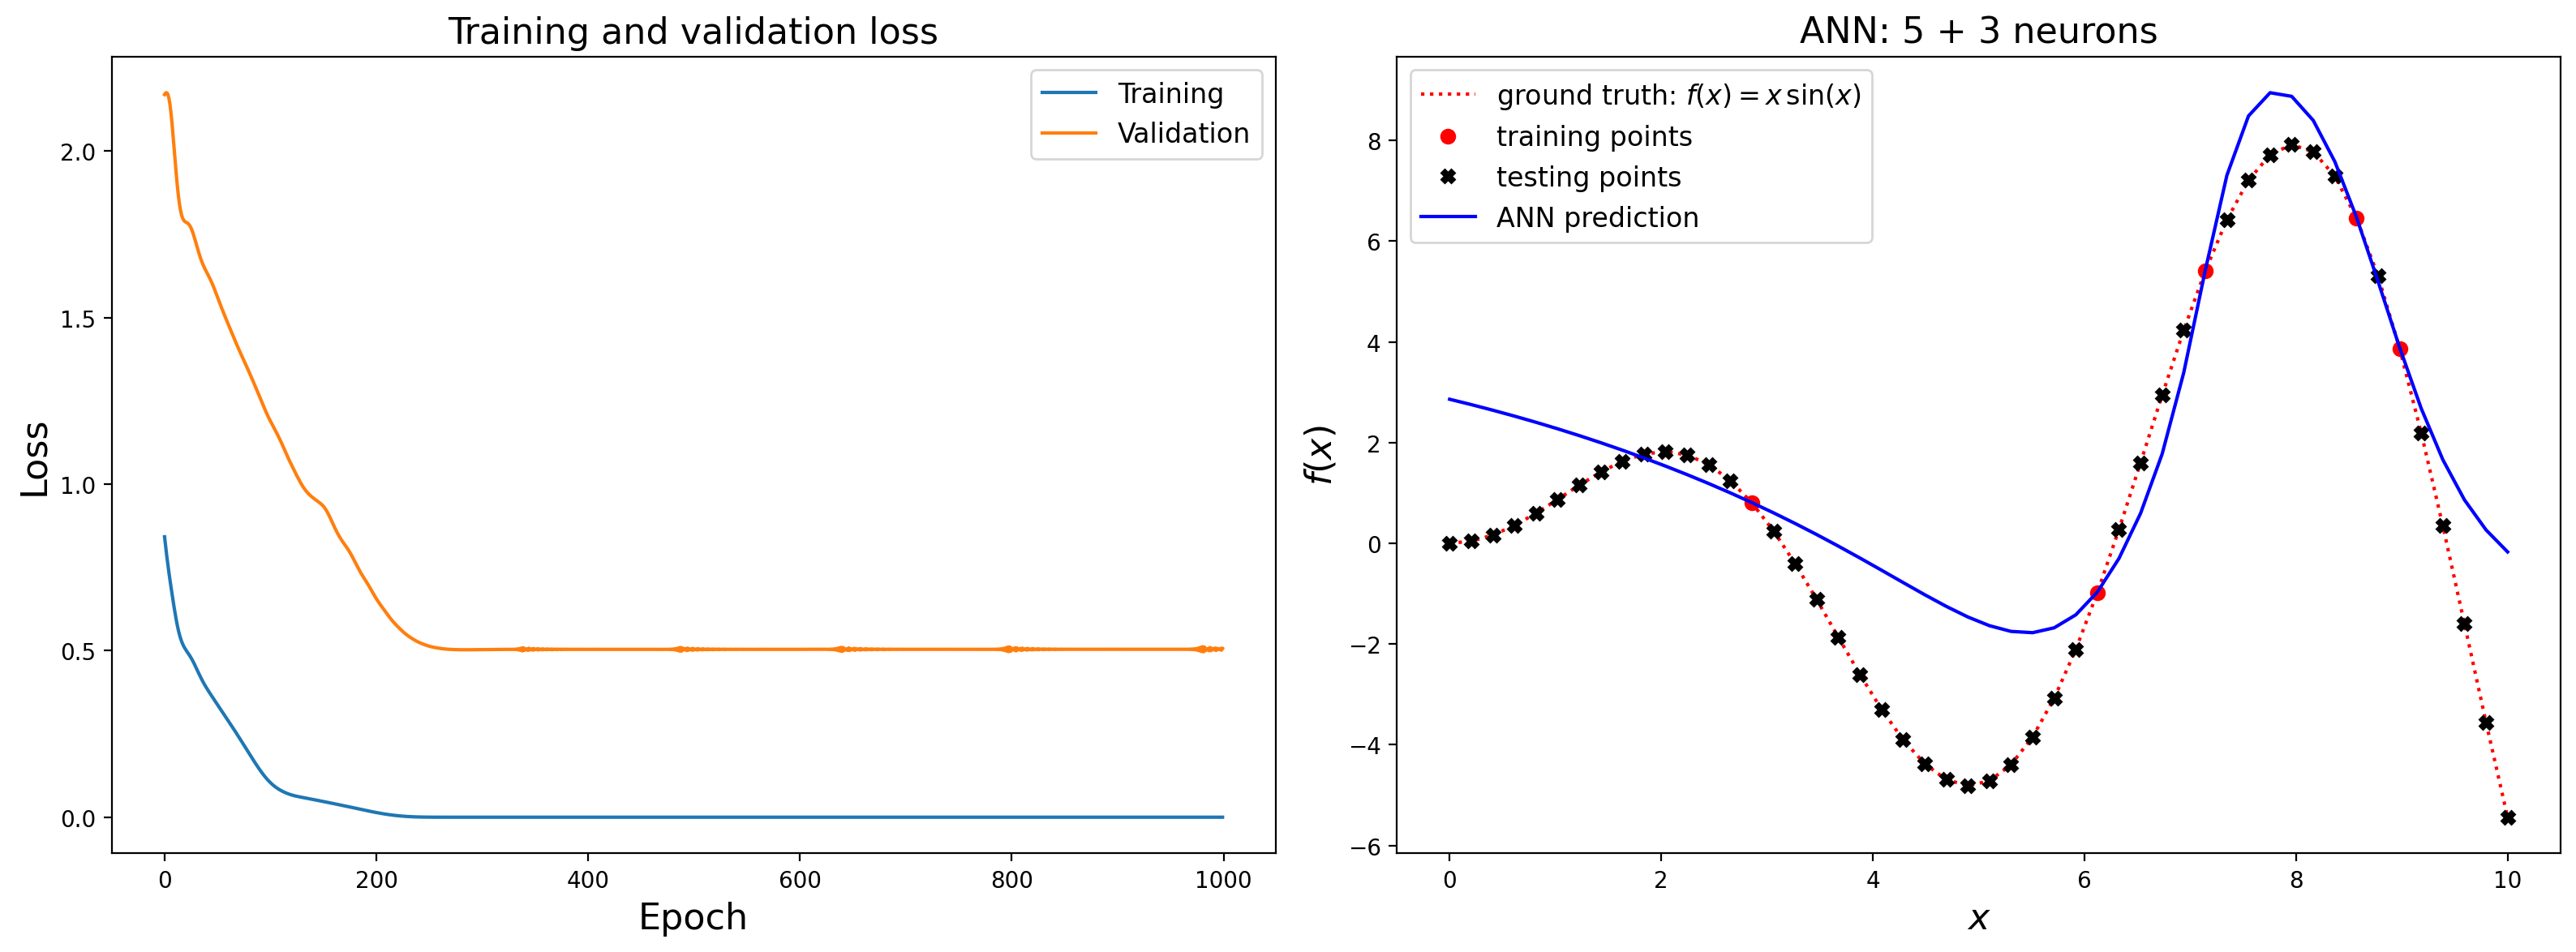

In [21]:
# Visualize training results
fig_ann, (ax1_ann, ax2_ann) = plt.subplots(1, 2)

# Loss history
ax1_ann.plot(train_losses, label="Training")
ax1_ann.plot(val_losses, label="Validation")
ax1_ann.set_title('Training and validation loss', fontsize=16)
ax1_ann.set_ylabel('Loss', fontsize=16)
ax1_ann.set_xlabel('Epoch', fontsize=16)
ax1_ann.legend(fontsize=12)

# ANN prediction
ax2_ann.plot(x_data, y_data, 'r:', label=r'ground truth: $f(x) = x\,\sin(x)$')
ax2_ann.plot(x_train, y_train, 'ro', markersize=6, label="training points")
ax2_ann.plot(x_test, y_test, 'kX', markersize=6, label="testing points")

# Predict and unscale
Y_data_scaled_pred = ANN_model(X_data_scaled).detach()
Y_data_pred = scaler_y.inverse_transform(Y_data_scaled_pred)
ax2_ann.plot(x_data, Y_data_pred.ravel(), 'b-', label="ANN prediction")
ax2_ann.set_title(f'ANN: {neurons1} + {neurons2} neurons', fontsize=16)
ax2_ann.set_xlabel('$x$', fontsize=16)
ax2_ann.set_ylabel('$f(x)$', fontsize=16)
ax2_ann.legend(loc='upper left', fontsize=12)

fig_ann.set_size_inches(16, 6)
plt.tight_layout()

## What is backpropagation?

When we call `loss.backward()`, PyTorch computes **all gradients** of the loss w.r.t. every parameter.

How? The loss is a **composition** of functions:

$$L = \text{loss}\big(\underbrace{f_{\text{out}}(\mathbf{W}_2 \cdot \underbrace{f_2(\mathbf{W}_1 \cdot \underbrace{f_1(\mathbf{W}_0 \mathbf{x} + \mathbf{b}_0)}_{\text{layer 1}} + \mathbf{b}_1)}_{\text{layer 2}} + \mathbf{b}_2)}_{\text{output}},\; \mathbf{y}\big)$$

The **chain rule** gives us:
$$\frac{\partial L}{\partial \mathbf{W}_0} = \frac{\partial L}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{n}_2} \cdot \frac{\partial \mathbf{n}_2}{\partial \mathbf{n}_1} \cdot \frac{\partial \mathbf{n}_1}{\partial \mathbf{W}_0}$$

We compute this **backward** from the loss to the parameters — hence **backpropagation**.

## Automatic differentiation

How does PyTorch compute all these derivatives? **Automatic differentiation** (autodiff).

Four ways to compute derivatives:

| Method | Exact? | Scalable? |
|---|---|---|
| Hand calculation | Yes | No (error-prone) |
| Finite differences | No (approximate) | No ($N$ evaluations for $N$ parameters!) |
| Symbolic differentiation | Yes | No (expression swell) |
| **Automatic differentiation** | **Yes** | **Yes** |

Autodiff decomposes any function into elementary operations, applies the chain rule, and computes exact derivatives efficiently.

## Forward-mode vs reverse-mode autodiff

Autodiff has two modes:

**Forward-mode:** Seed one input → get derivatives of **all outputs** w.r.t. that input
- Efficient when: few inputs, many outputs
- One pass gives one **column** of the Jacobian

**Reverse-mode:** Seed one output → get derivatives of that output w.r.t. **all inputs**
- Efficient when: many inputs, few outputs
- One pass gives one **row** of the Jacobian (= the **gradient**!)

In ML: we have **many parameters** (inputs) and **one scalar loss** (output).

$\Rightarrow$ **Reverse-mode** is ideal for ML — and it's exactly **backpropagation**!

## The Jacobian matrix

For a function $\mathbf{f}: \mathbb{R}^n \rightarrow \mathbb{R}^m$, the Jacobian is the $m \times n$ matrix:

$$\mathcal{J} = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}\end{bmatrix}$$

- **Forward-mode** computes one column per pass → need $n$ passes for full Jacobian
- **Reverse-mode** computes one row per pass → need $m$ passes for full Jacobian

For ML: $n$ = millions of parameters, $m = 1$ (loss) → reverse-mode needs just **1 pass**!

## Summary: the training pipeline

```
1. Standardize data → convert to tensors
2. Define model architecture (layers, activations)
3. Choose loss function (MSE for regression, cross-entropy for classification)
4. Choose optimizer (Adam is a good default)
5. Training loop:
   - Forward pass (compute predictions)
   - Compute loss
   - Backward pass (autodiff computes gradients via backpropagation)
   - Optimizer updates parameters
6. Evaluate on test set
```

PyTorch handles steps 5c automatically — you just call `loss.backward()`!

### In-class Exercise

Modify the ANN training code above and observe the effects:

1. **Change neurons:** Set `neurons1=20, neurons2=10` — does the fit improve?
2. **Change learning rate:** Try `lr=0.1` and `lr=0.001` — what happens?
3. **Use more training data:** Change `testset_ratio=0.50` — how does this help?
4. **Try 1 hidden layer:** Modify the `ANN` class to use only 1 hidden layer with 10 neurons
5. **Switch activation:** Change `nn.Tanh()` to `nn.ReLU()` — compare the predictions

In [22]:
# Write your code for the In-class Exercise:

# until here.

<details>
<summary><b>Click here for Solution (example: 1 hidden layer with ReLU)</b></summary>

```python
class ANN_1layer(nn.Module):
    def __init__(self, input_dimensions=1, neurons1=10, output_dimensions=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dimensions, neurons1),
            nn.ReLU(),
            nn.Linear(neurons1, output_dimensions)
        )
    def forward(self, x):
        return self.net(x)

model_1L = ANN_1layer(neurons1=10)
opt_1L = Adam(model_1L.parameters(), lr=0.01)
loss_fn_1L = nn.MSELoss()

for epoch in range(1000):
    model_1L.train()
    pred = model_1L(X_train_scaled)
    loss = loss_fn_1L(pred, Y_train_scaled)
    opt_1L.zero_grad()
    loss.backward()
    opt_1L.step()

Y_pred_1L = scaler_y.inverse_transform(model_1L(X_data_scaled).detach())
plt.plot(x_data, y_data, "r:", label="ground truth")
plt.plot(x_data, Y_pred_1L.ravel(), "b-", label="1-layer ReLU")
plt.plot(x_train, y_train, "ro", markersize=6, label="training")
plt.legend()
```
</details>

## Key Takeaways from Lecture 4

**Part I: Classification and Logistic Regression**
- Classification uses discrete distributions: Bernoulli (binary) / Categorical (multiclass)
- The **sigmoid** maps $\mathbb{R} \rightarrow [0,1]$; the **softmax** generalizes to $C$ classes
- Cross-entropy loss comes from the NLL of the Bernoulli/Categorical distribution
- No closed-form solution (unlike linear regression) → numerical optimization (L-BFGS)

**Part II: Neural Networks**
- Logistic regression is a **single-layer network**; stacking layers gives deep networks
- **Nonlinear activations** are essential (linear composition collapses)
- Loss functions come from the Bayesian framework (MSE for regression, cross-entropy for classification)
- **Backpropagation** = reverse-mode automatic differentiation
- PyTorch handles gradient computation automatically via `loss.backward()`

## Thank you!

Questions?